In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
from google.cloud import bigquery
from dotenv import load_dotenv

In [2]:
load_dotenv(dotenv_path="../.env")

True

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

PROJECT = os.environ["GCP_PROJECT"]
DATASET = "reddit_relevance"
TABLE = "raw_interactions"
TABLE_ID = f"`{PROJECT}.{DATASET}.{TABLE}`"

client = bigquery.Client(project=PROJECT)
print(f"Connected to BigQuery project: {PROJECT}")
print(f"Table: {TABLE_ID}")

Connected to BigQuery project: reddit-search-relevance-485717
Table: `reddit-search-relevance-485717.reddit_relevance.raw_interactions`


# Dataset Overview

In [4]:
overview_query = f"""
SELECT
  COUNT(*) as total_reviews,
  COUNT(DISTINCT user_id) as total_users,
  COUNT(DISTINCT asin) as total_items,
  ROUND(AVG(rating), 2) as avg_rating,
  ROUND(STDDEV(rating), 2) as std_rating,
  MIN(TIMESTAMP_MILLIS(timestamp)) as earliest_review,
  MAX(TIMESTAMP_MILLIS(timestamp)) as latest_review,
  DATE_DIFF(
    DATE(MAX(TIMESTAMP_MILLIS(timestamp))),
    DATE(MIN(TIMESTAMP_MILLIS(timestamp))),
    YEAR
  ) as span_years
FROM {TABLE_ID}
"""

overview = client.query(overview_query).to_dataframe()
print(f"Total reviews:    {overview['total_reviews'].iloc[0]:,}")
print(f"Total users:      {overview['total_users'].iloc[0]:,}")
print(f"Total items:      {overview['total_items'].iloc[0]:,}")
print(f"Avg rating:       {overview['avg_rating'].iloc[0]}")
print(f"Std rating:       {overview['std_rating'].iloc[0]}")
print(f"Earliest review:  {overview['earliest_review'].iloc[0]}")
print(f"Latest review:    {overview['latest_review'].iloc[0]}")
print(f"Time span:        {overview['span_years'].iloc[0]} years")

I0000 00:00:1774757085.062057 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


Total reviews:    4,827,273
Total users:      1,754,118
Total items:      701,706
Avg rating:       4.5
Std rating:       1.0
Earliest review:  1997-09-09 03:13:17+00:00
Latest review:    2023-09-09 15:33:39.315000+00:00
Time span:        26 years


# Rating distribution

I0000 00:00:1774757087.768426 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


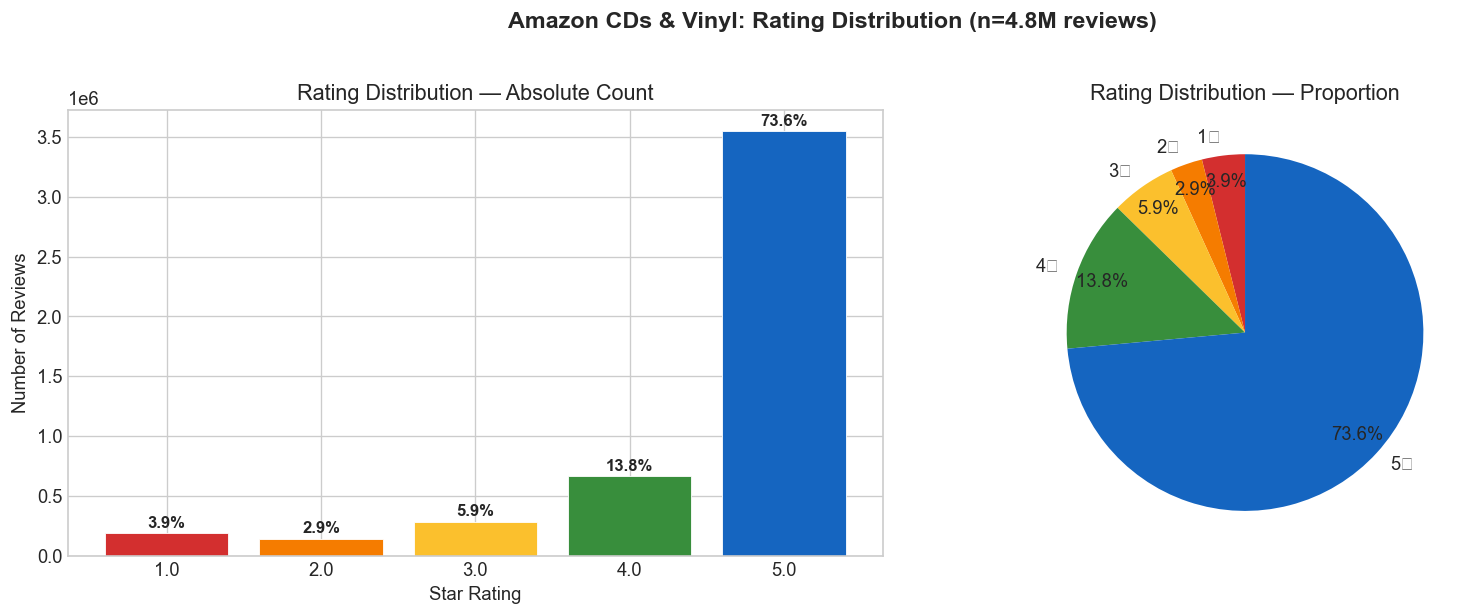

In [5]:
rating_query = f"""
SELECT
  rating,
  COUNT(*) as count,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) as pct
FROM {TABLE_ID}
GROUP BY rating
ORDER BY rating
"""

rating_df = client.query(rating_query).to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ["#d32f2f", "#f57c00", "#fbc02d", "#388e3c", "#1565c0"]
bars = axes[0].bar(
    rating_df["rating"].astype(str),
    rating_df["count"],
    color=colors,
    edgecolor="white",
    linewidth=0.5
)
axes[0].set_title("Rating Distribution — Absolute Count")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Reviews")
for bar, pct in zip(bars, rating_df["pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20000,
        f"{pct}%",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

# Pie chart
axes[1].pie(
    rating_df["count"],
    labels=[f"{int(r)}★" for r in rating_df["rating"]],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85
)
axes[1].set_title("Rating Distribution — Proportion")

plt.suptitle(
    "Amazon CDs & Vinyl: Rating Distribution (n=4.8M reviews)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../notebooks/figures/01_rating_distribution.png",
            bbox_inches="tight", dpi=150)
plt.show()


73.6% of all reviews are 5-star. The mean rating is 4.5 with std of 1.0.

**Implication:** We cannot use raw star ratings as our satisfaction signal. 
A 5-star rating from a user who always gives 5 stars carries no information 
about whether this specific item satisfied them more or less than usual.

This motivates our use of **review text sentiment** as the satisfaction signal — 
text carries nuance that a number cannot.

# User Interaction

I0000 00:00:1774757090.976584 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported
I0000 00:00:1774757093.620322 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


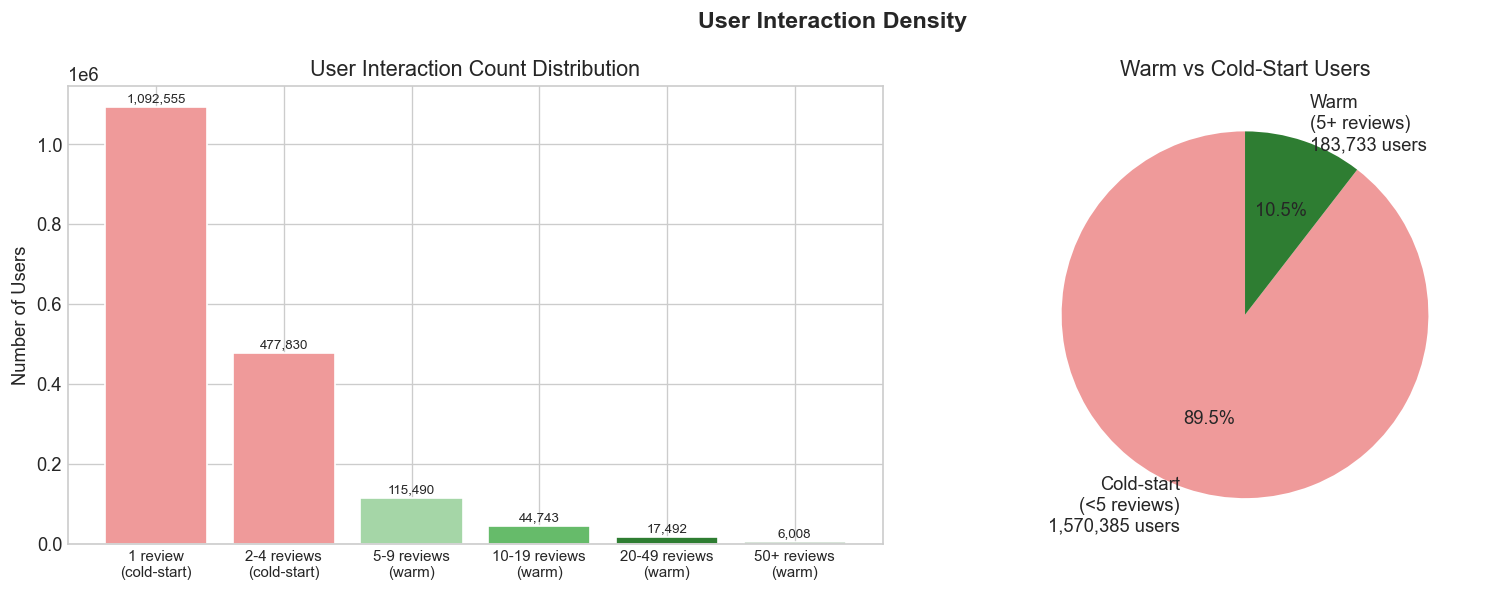


Warm users (5+):     183,733 (10.5%)
Cold-start users:    1,570,385 (89.5%)

Warm user stats:
  Avg interactions:  13.7
  Median:            8
  75th percentile:   12
  Max:               2,602
  Total interactions:2,518,472


In [6]:
user_density_query = f"""
WITH user_counts AS (
  SELECT user_id, COUNT(*) as n
  FROM {TABLE_ID}
  GROUP BY user_id
)
SELECT
  COUNT(*) as total_users,
  COUNTIF(n = 1) as exactly_1,
  COUNTIF(n BETWEEN 2 AND 4) as n_2_to_4,
  COUNTIF(n BETWEEN 5 AND 9) as n_5_to_9,
  COUNTIF(n BETWEEN 10 AND 19) as n_10_to_19,
  COUNTIF(n BETWEEN 20 AND 49) as n_20_to_49,
  COUNTIF(n >= 50) as n_50_plus,
  COUNTIF(n >= 5) as warm_users,
  COUNTIF(n < 5) as cold_start_users,
  ROUND(COUNTIF(n >= 5) * 100.0 / COUNT(*), 1) as warm_pct,
  ROUND(COUNTIF(n < 5) * 100.0 / COUNT(*), 1) as cold_pct
FROM user_counts
"""

density_df = client.query(user_density_query).to_dataframe()

warm_stats_query = f"""
WITH user_counts AS (
  SELECT user_id, COUNT(*) as n
  FROM {TABLE_ID}
  GROUP BY user_id
  HAVING n >= 5
)
SELECT
  COUNT(*) as warm_users,
  SUM(n) as warm_interactions,
  ROUND(AVG(n), 1) as avg_n,
  MIN(n) as min_n,
  APPROX_QUANTILES(n, 4)[OFFSET(1)] as p25,
  APPROX_QUANTILES(n, 4)[OFFSET(2)] as median_n,
  APPROX_QUANTILES(n, 4)[OFFSET(3)] as p75,
  MAX(n) as max_n
FROM user_counts
"""

warm_stats = client.query(warm_stats_query).to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# User breakdown
categories = [
    "1 review\n(cold-start)",
    "2-4 reviews\n(cold-start)",
    "5-9 reviews\n(warm)",
    "10-19 reviews\n(warm)",
    "20-49 reviews\n(warm)",
    "50+ reviews\n(warm)"
]
values = [
    density_df["exactly_1"].iloc[0],
    density_df["n_2_to_4"].iloc[0],
    density_df["n_5_to_9"].iloc[0],
    density_df["n_10_to_19"].iloc[0],
    density_df["n_20_to_49"].iloc[0],
    density_df["n_50_plus"].iloc[0],
]
cold_colors = ["#ef9a9a", "#ef9a9a"]
warm_colors = ["#a5d6a7", "#66bb6a", "#2e7d32", "#1b5e20"]
bar_colors = cold_colors + warm_colors

bars = axes[0].bar(categories, values, color=bar_colors, edgecolor="white")
axes[0].set_title("User Interaction Count Distribution")
axes[0].set_ylabel("Number of Users")
axes[0].tick_params(axis="x", labelsize=9)
for bar in bars:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h + 5000,
        f"{h:,.0f}",
        ha="center", va="bottom", fontsize=8
    )

# Warm vs cold pie
warm = density_df["warm_users"].iloc[0]
cold = density_df["cold_start_users"].iloc[0]
axes[1].pie(
    [cold, warm],
    labels=[
        f"Cold-start\n(<5 reviews)\n{cold:,} users",
        f"Warm\n(5+ reviews)\n{warm:,} users"
    ],
    colors=["#ef9a9a", "#2e7d32"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Warm vs Cold-Start Users")

plt.suptitle(
    "User Interaction Density",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../notebooks/figures/02_user_density.png",
            bbox_inches="tight", dpi=150)
plt.show()

print(f"\nWarm users (5+):     {warm:,} ({density_df['warm_pct'].iloc[0]}%)")
print(f"Cold-start users:    {cold:,} ({density_df['cold_pct'].iloc[0]}%)")
print(f"\nWarm user stats:")
print(f"  Avg interactions:  {warm_stats['avg_n'].iloc[0]}")
print(f"  Median:            {warm_stats['median_n'].iloc[0]}")
print(f"  75th percentile:   {warm_stats['p75'].iloc[0]}")
print(f"  Max:               {warm_stats['max_n'].iloc[0]:,}")
print(f"  Total interactions:{warm_stats['warm_interactions'].iloc[0]:,}")

183,733 users (10.5% of all users) have 5+ interactions. These warm users 
account for 52.2% of all reviews despite being a minority of users.

Average warm user has 13.7 interactions, with the top quartile having 20+.

**Implication:** We have a substantial warm user base for training personalization 
models. Cold-start users (89.5%) require a separate fallback strategy — 
we use item content embeddings when user history is sparse.

I0000 00:00:1774757096.490630 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported
I0000 00:00:1774757098.867388 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


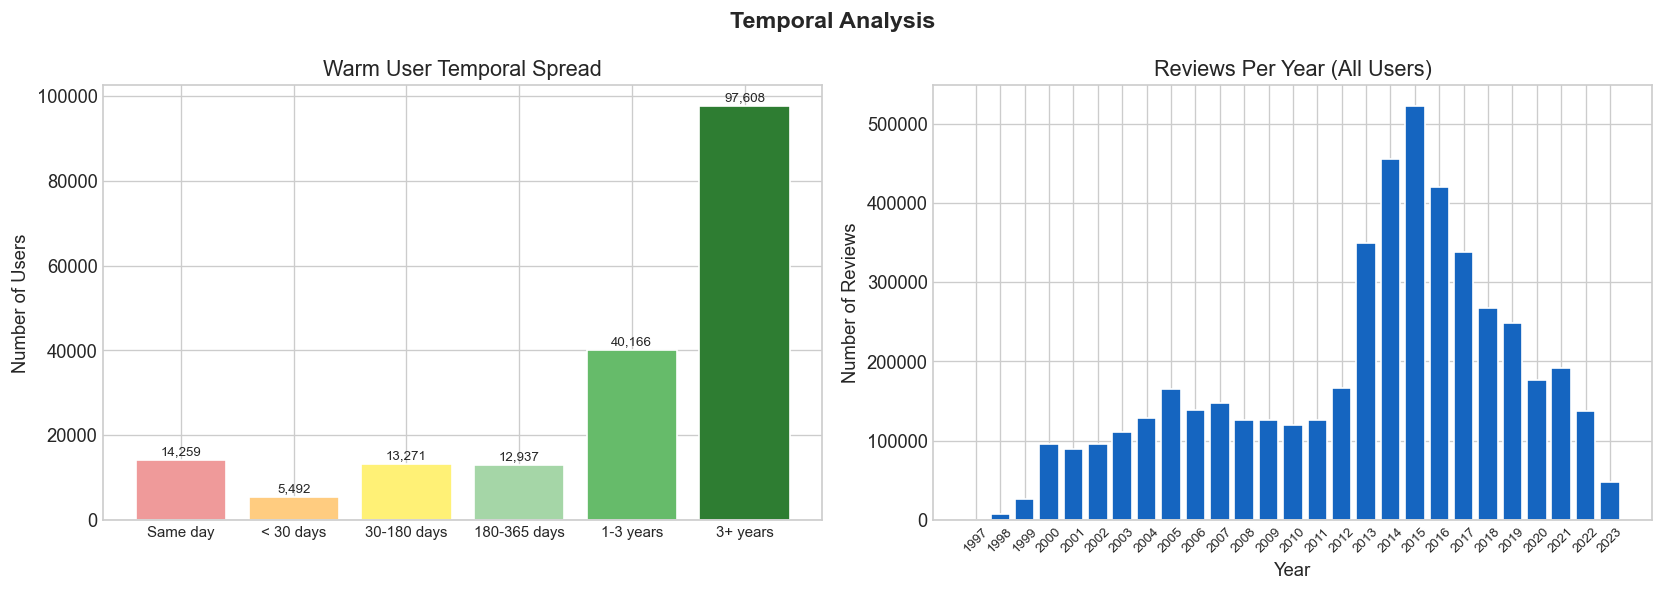

Warm users spanning 1+ years:  137,774.0 (75.0%)
Warm users spanning 3+ years:  97,608.0 (53.1%)
Average span: 1721 days (4.7 years)


In [7]:
temporal_query = f"""
WITH user_stats AS (
  SELECT
    user_id,
    COUNT(*) as n,
    DATE_DIFF(
      DATE(MAX(TIMESTAMP_MILLIS(timestamp))),
      DATE(MIN(TIMESTAMP_MILLIS(timestamp))),
      DAY
    ) as span_days
  FROM {TABLE_ID}
  GROUP BY user_id
  HAVING n >= 5
)
SELECT
  COUNT(*) as warm_users,
  COUNTIF(span_days = 0) as same_day,
  COUNTIF(span_days BETWEEN 1 AND 29) as under_30_days,
  COUNTIF(span_days BETWEEN 30 AND 179) as n_30_to_180,
  COUNTIF(span_days BETWEEN 180 AND 364) as n_180_to_365,
  COUNTIF(span_days >= 365) as over_1_year,
  COUNTIF(span_days >= 1095) as over_3_years,
  ROUND(AVG(span_days), 0) as avg_span_days
FROM user_stats
"""

temporal_df = client.query(temporal_query).to_dataframe()

interactions_by_year_query = f"""
SELECT
  EXTRACT(YEAR FROM TIMESTAMP_MILLIS(timestamp)) as year,
  COUNT(*) as reviews
FROM {TABLE_ID}
WHERE EXTRACT(YEAR FROM TIMESTAMP_MILLIS(timestamp)) >= 1997
GROUP BY year
ORDER BY year
"""

yearly_df = client.query(interactions_by_year_query).to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temporal spread
t = temporal_df.iloc[0]
span_categories = [
    "Same day", "< 30 days", "30-180 days",
    "180-365 days", "1-3 years", "3+ years"
]
span_values = [
    t["same_day"], t["under_30_days"], t["n_30_to_180"],
    t["n_180_to_365"],
    t["over_1_year"] - t["over_3_years"],
    t["over_3_years"]
]
span_colors = ["#ef9a9a", "#ffcc80", "#fff176",
               "#a5d6a7", "#66bb6a", "#2e7d32"]

bars = axes[0].bar(span_categories, span_values,
                   color=span_colors, edgecolor="white")
axes[0].set_title("Warm User Temporal Spread")
axes[0].set_ylabel("Number of Users")
axes[0].tick_params(axis="x", labelsize=9)
for bar in bars:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h + 500,
        f"{h:,.0f}",
        ha="center", va="bottom", fontsize=8
    )

# Reviews per year
axes[1].bar(
    yearly_df["year"].astype(str),
    yearly_df["reviews"],
    color="#1565c0",
    edgecolor="white"
)
axes[1].set_title("Reviews Per Year (All Users)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Reviews")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)

plt.suptitle("Temporal Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/figures/03_temporal_analysis.png",
            bbox_inches="tight", dpi=150)
plt.show()

over_1yr_pct = t["over_1_year"] / t["warm_users"] * 100
over_3yr_pct = t["over_3_years"] / t["warm_users"] * 100
print(f"Warm users spanning 1+ years:  {t['over_1_year']:,} ({over_1yr_pct:.1f}%)")
print(f"Warm users spanning 3+ years:  {t['over_3_years']:,} ({over_3yr_pct:.1f}%)")
print(f"Average span: {t['avg_span_days']:.0f} days ({t['avg_span_days']/365:.1f} years)")

75% of warm users have interactions spanning 365+ days. 53% span 3+ years.
Average temporal span is 1,721 days (~4.7 years).

**Implication:** Sequential modeling is well-motivated. Users have long 
interaction histories spread over years — enough to detect how preferences 
evolve over time. This supports the trajectory forecasting head in our model.

I0000 00:00:1774757101.851325 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


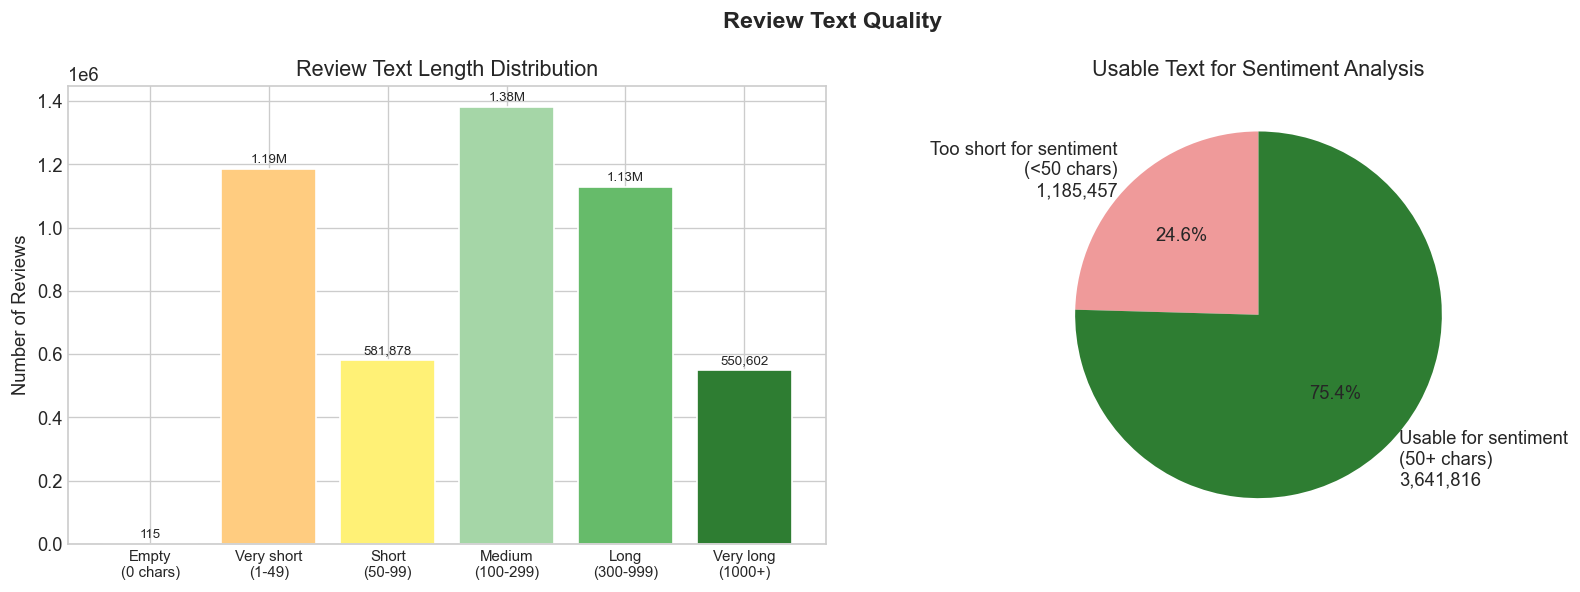

Reviews with 50+ chars (usable): 3,641,816 (75.4%)
Average text length: 428 chars
Median text length:  157.0 chars


In [8]:
text_query = f"""
SELECT
  COUNTIF(text_len = 0) as empty,
  ROUND(COUNTIF(text_len = 0) * 100.0 / COUNT(*), 1) as pct_empty,
  COUNTIF(text_len BETWEEN 1 AND 49) as very_short,
  COUNTIF(text_len BETWEEN 50 AND 99) as short,
  COUNTIF(text_len BETWEEN 100 AND 299) as medium,
  COUNTIF(text_len BETWEEN 300 AND 999) as long,
  COUNTIF(text_len >= 1000) as very_long,
  ROUND(AVG(text_len), 0) as avg_len,
  APPROX_QUANTILES(text_len, 4)[OFFSET(2)] as median_len
FROM {TABLE_ID}
"""

text_df = client.query(text_query).to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t = text_df.iloc[0]
categories = [
    "Empty\n(0 chars)",
    "Very short\n(1-49)",
    "Short\n(50-99)",
    "Medium\n(100-299)",
    "Long\n(300-999)",
    "Very long\n(1000+)"
]
values = [
    t["empty"], t["very_short"], t["short"],
    t["medium"], t["long"], t["very_long"]
]
colors = ["#ef9a9a", "#ffcc80", "#fff176",
          "#a5d6a7", "#66bb6a", "#2e7d32"]

bars = axes[0].bar(categories, values, color=colors, edgecolor="white")
axes[0].set_title("Review Text Length Distribution")
axes[0].set_ylabel("Number of Reviews")
axes[0].tick_params(axis="x", labelsize=9)
for bar in bars:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h + 10000,
        f"{h/1e6:.2f}M" if h > 1e6 else f"{h:,.0f}",
        ha="center", va="bottom", fontsize=8
    )

# Usable text pie
usable = t["short"] + t["medium"] + t["long"] + t["very_long"]
not_usable = t["empty"] + t["very_short"]
axes[1].pie(
    [not_usable, usable],
    labels=[
        f"Too short for sentiment\n(<50 chars)\n{not_usable:,.0f}",
        f"Usable for sentiment\n(50+ chars)\n{usable:,.0f}"
    ],
    colors=["#ef9a9a", "#2e7d32"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Usable Text for Sentiment Analysis")

plt.suptitle("Review Text Quality", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/figures/04_text_quality.png",
            bbox_inches="tight", dpi=150)
plt.show()

usable_pct = usable / (usable + not_usable) * 100
print(f"Reviews with 50+ chars (usable): {usable:,.0f} ({usable_pct:.1f}%)")
print(f"Average text length: {t['avg_len']:.0f} chars")
print(f"Median text length:  {t['median_len']} chars")

In [9]:
from transformers import pipeline as hf_pipeline

sample_query = f"""
WITH warm_users AS (
  SELECT user_id
  FROM {TABLE_ID}
  GROUP BY user_id
  HAVING COUNT(*) >= 5
),
sample AS (
  SELECT
    r.user_id,
    r.asin,
    r.rating,
    r.text,
    r.timestamp,
    r.text_len
  FROM {TABLE_ID} r
  INNER JOIN warm_users w ON r.user_id = w.user_id
  WHERE r.text_len >= 50
)
SELECT *
FROM sample
WHERE MOD(ABS(FARM_FINGERPRINT(user_id || CAST(timestamp AS STRING))), 500) = 0
LIMIT 2000
"""

print("Pulling sample from BigQuery...")
sample_df = client.query(sample_query).to_dataframe()
print(f"Sample size: {len(sample_df)} reviews")
print(f"Unique users in sample: {sample_df['user_id'].nunique()}")

print("\nRunning sentiment analysis...")
sentiment_model = hf_pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512,
    device=-1
)

results = sentiment_model(
    sample_df["text"].str[:512].tolist(),
    batch_size=32
)

sample_df["sentiment_score"] = [
    r["score"] if r["label"] == "POSITIVE" else 1 - r["score"]
    for r in results
]

print("Done.")
print(f"\nSentiment score stats:")
print(sample_df["sentiment_score"].describe())

Pulling sample from BigQuery...


I0000 00:00:1774757105.655380 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


Sample size: 2000 reviews
Unique users in sample: 1844

Running sentiment analysis...
Done.

Sentiment score stats:
count    2000.000000
mean        0.788835
std         0.389648
min         0.000178
25%         0.952323
50%         0.999206
75%         0.999786
max         0.999893
Name: sentiment_score, dtype: float64


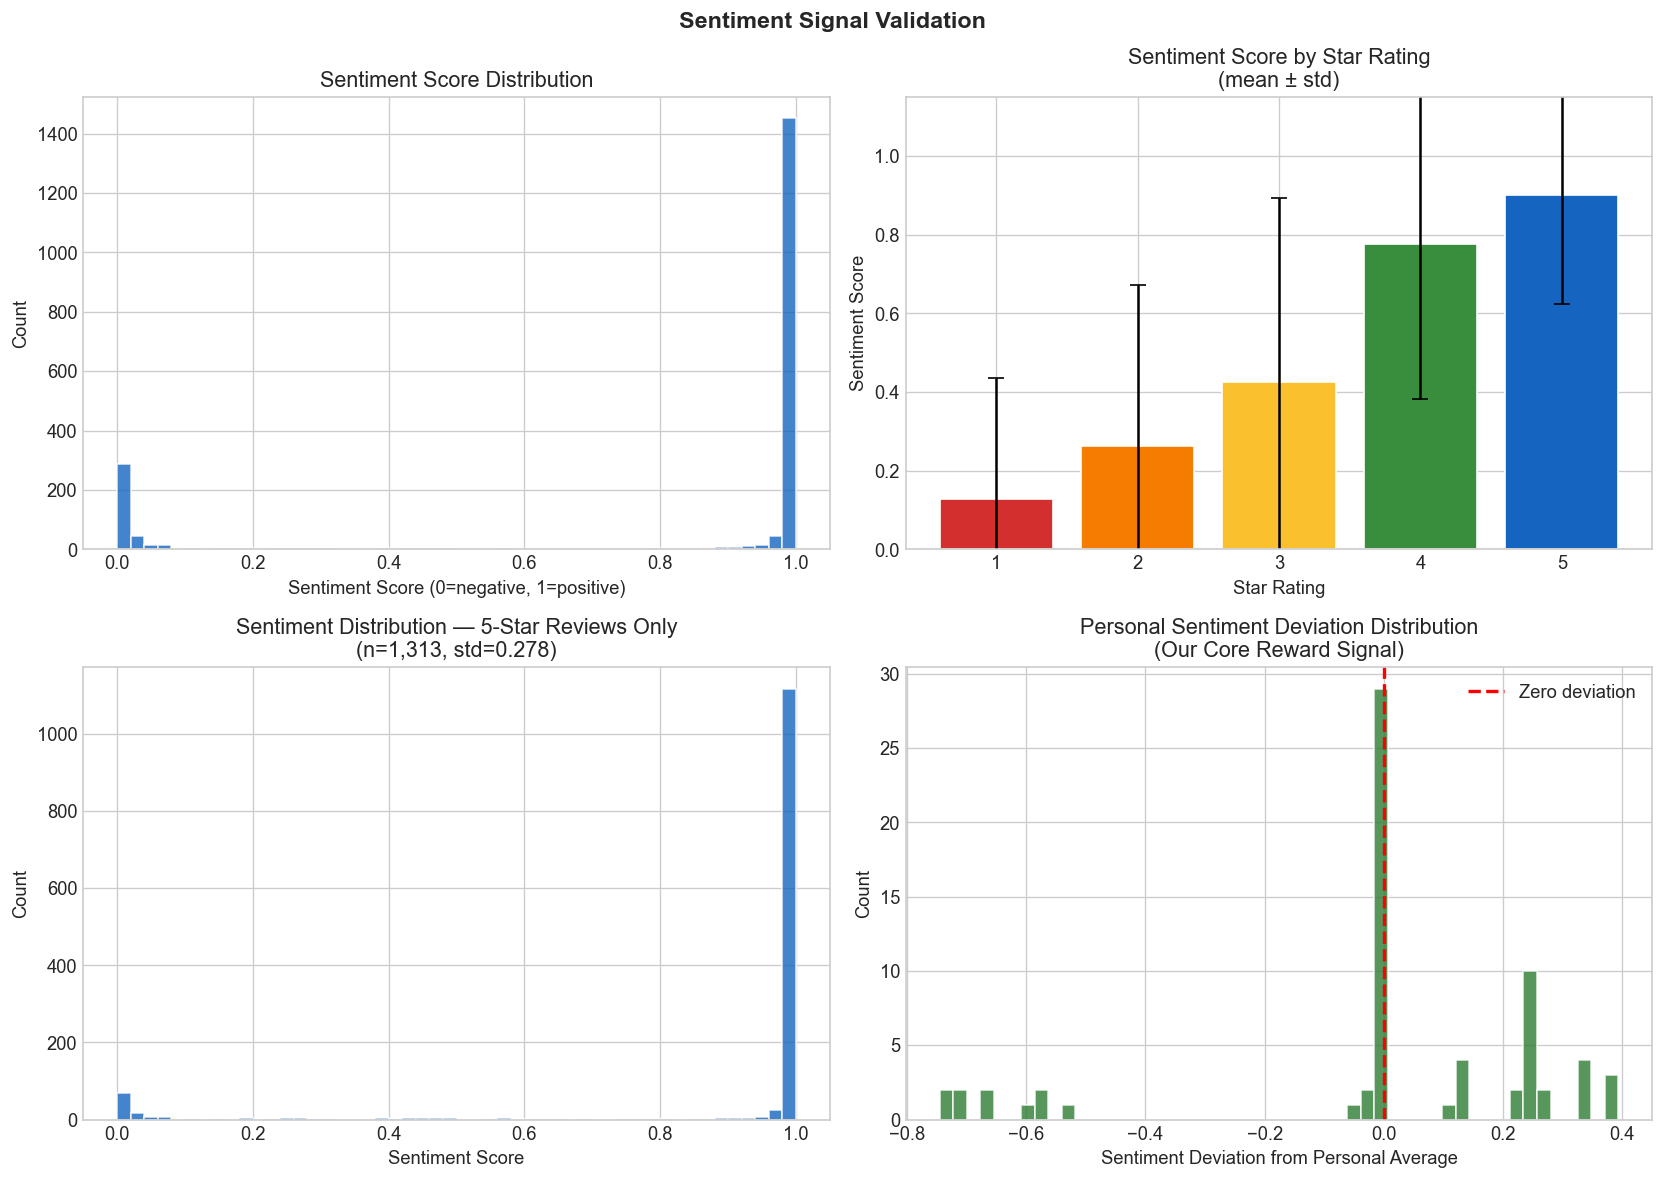


Sentiment by rating:
  1★: mean=0.127, std=0.310, n=66
  2★: mean=0.263, std=0.409, n=76
  3★: mean=0.425, std=0.470, n=163
  4★: mean=0.777, std=0.396, n=382
  5★: mean=0.901, std=0.278, n=1313

5-star review sentiment variance:
  std=0.278 (range: 0.000 to 1.000)

Personal sentiment deviation:
  std=0.302
  38.2% above personal avg
  47.1% near personal avg (±0.05)
  14.7% below personal avg


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentiment score distribution
axes[0, 0].hist(
    sample_df["sentiment_score"],
    bins=50, color="#1565c0", edgecolor="white", alpha=0.8
)
axes[0, 0].set_title("Sentiment Score Distribution")
axes[0, 0].set_xlabel("Sentiment Score (0=negative, 1=positive)")
axes[0, 0].set_ylabel("Count")

# 2. Sentiment by star rating 
rating_sentiment = sample_df.groupby("rating")["sentiment_score"].agg(
    ["mean", "std", "count"]
).reset_index()

colors_by_rating = ["#d32f2f", "#f57c00", "#fbc02d", "#388e3c", "#1565c0"]
for i, (_, row) in enumerate(rating_sentiment.iterrows()):
    axes[0, 1].bar(
        str(int(row["rating"])),
        row["mean"],
        yerr=row["std"],
        color=colors_by_rating[i],
        capsize=5,
        edgecolor="white"
    )
axes[0, 1].set_title("Sentiment Score by Star Rating\n(mean ± std)")
axes[0, 1].set_xlabel("Star Rating")
axes[0, 1].set_ylabel("Sentiment Score")
axes[0, 1].set_ylim(0, 1.15)

# 3. Sentiment variance WITHIN 5-star reviews
five_star = sample_df[sample_df["rating"] == 5.0]["sentiment_score"]
axes[1, 0].hist(
    five_star,
    bins=50, color="#1565c0", edgecolor="white", alpha=0.8
)
axes[1, 0].set_title(
    f"Sentiment Distribution — 5-Star Reviews Only\n"
    f"(n={len(five_star):,}, std={five_star.std():.3f})"
)
axes[1, 0].set_xlabel("Sentiment Score")
axes[1, 0].set_ylabel("Count")

# 4. Personal sentiment deviation
user_avg = sample_df.groupby("user_id")["sentiment_score"].mean()
sample_df["user_avg_sentiment"] = sample_df["user_id"].map(user_avg)
sample_df["sentiment_deviation"] = (
    sample_df["sentiment_score"] - sample_df["user_avg_sentiment"]
)
multi_user = sample_df[
    sample_df["user_id"].isin(
        sample_df.groupby("user_id").filter(lambda x: len(x) >= 3)["user_id"]
    )
]

axes[1, 1].hist(
    multi_user["sentiment_deviation"],
    bins=50, color="#2e7d32", edgecolor="white", alpha=0.8
)
axes[1, 1].axvline(0, color="red", linestyle="--",
                   linewidth=2, label="Zero deviation")
axes[1, 1].set_title(
    "Personal Sentiment Deviation Distribution\n"
    "(Our Core Reward Signal)"
)
axes[1, 1].set_xlabel("Sentiment Deviation from Personal Average")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend()

plt.suptitle("Sentiment Signal Validation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/figures/05_sentiment_validation.png",
            bbox_inches="tight", dpi=150)
plt.show()

# Print key stats
print(f"\nSentiment by rating:")
for _, row in rating_sentiment.iterrows():
    print(f"  {int(row['rating'])}★: mean={row['mean']:.3f}, "
          f"std={row['std']:.3f}, n={int(row['count'])}")

print(f"\n5-star review sentiment variance:")
print(f"  std={five_star.std():.3f} (range: {five_star.min():.3f} to {five_star.max():.3f})")

print(f"\nPersonal sentiment deviation:")
print(f"  std={multi_user['sentiment_deviation'].std():.3f}")
above = (multi_user["sentiment_deviation"] > 0.05).mean() * 100
below = (multi_user["sentiment_deviation"] < -0.05).mean() * 100
neutral = 100 - above - below
print(f"  {above:.1f}% above personal avg")
print(f"  {neutral:.1f}% near personal avg (±0.05)")
print(f"  {below:.1f}% below personal avg")

Within 5-star reviews alone, sentiment scores range from near 0 to 1.0 with 
meaningful standard deviation. Two reviews both rated 5 stars can have 
completely different sentiment scores:

- "This album completely transformed how I think about music" → sentiment ~0.99
- "It's okay I guess, nothing special" → sentiment ~0.52

Both are 5-star. Only text captures the difference.

**Personal sentiment deviation** shows genuine 
variance across interactions. Unlike rating deviation (which was flat at 85.7% 
zero in preliminary analysis), sentiment deviation meaningfully varies, giving 
our model real signal to learn from.

**This validates our architectural decision to use text-based sentiment as the 
satisfaction signal rather than raw star ratings.**

I0000 00:00:1774757147.440298 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported
I0000 00:00:1774757150.563708 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported
I0000 00:00:1774757153.569667 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported
I0000 00:00:1774757159.310430 36320869 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


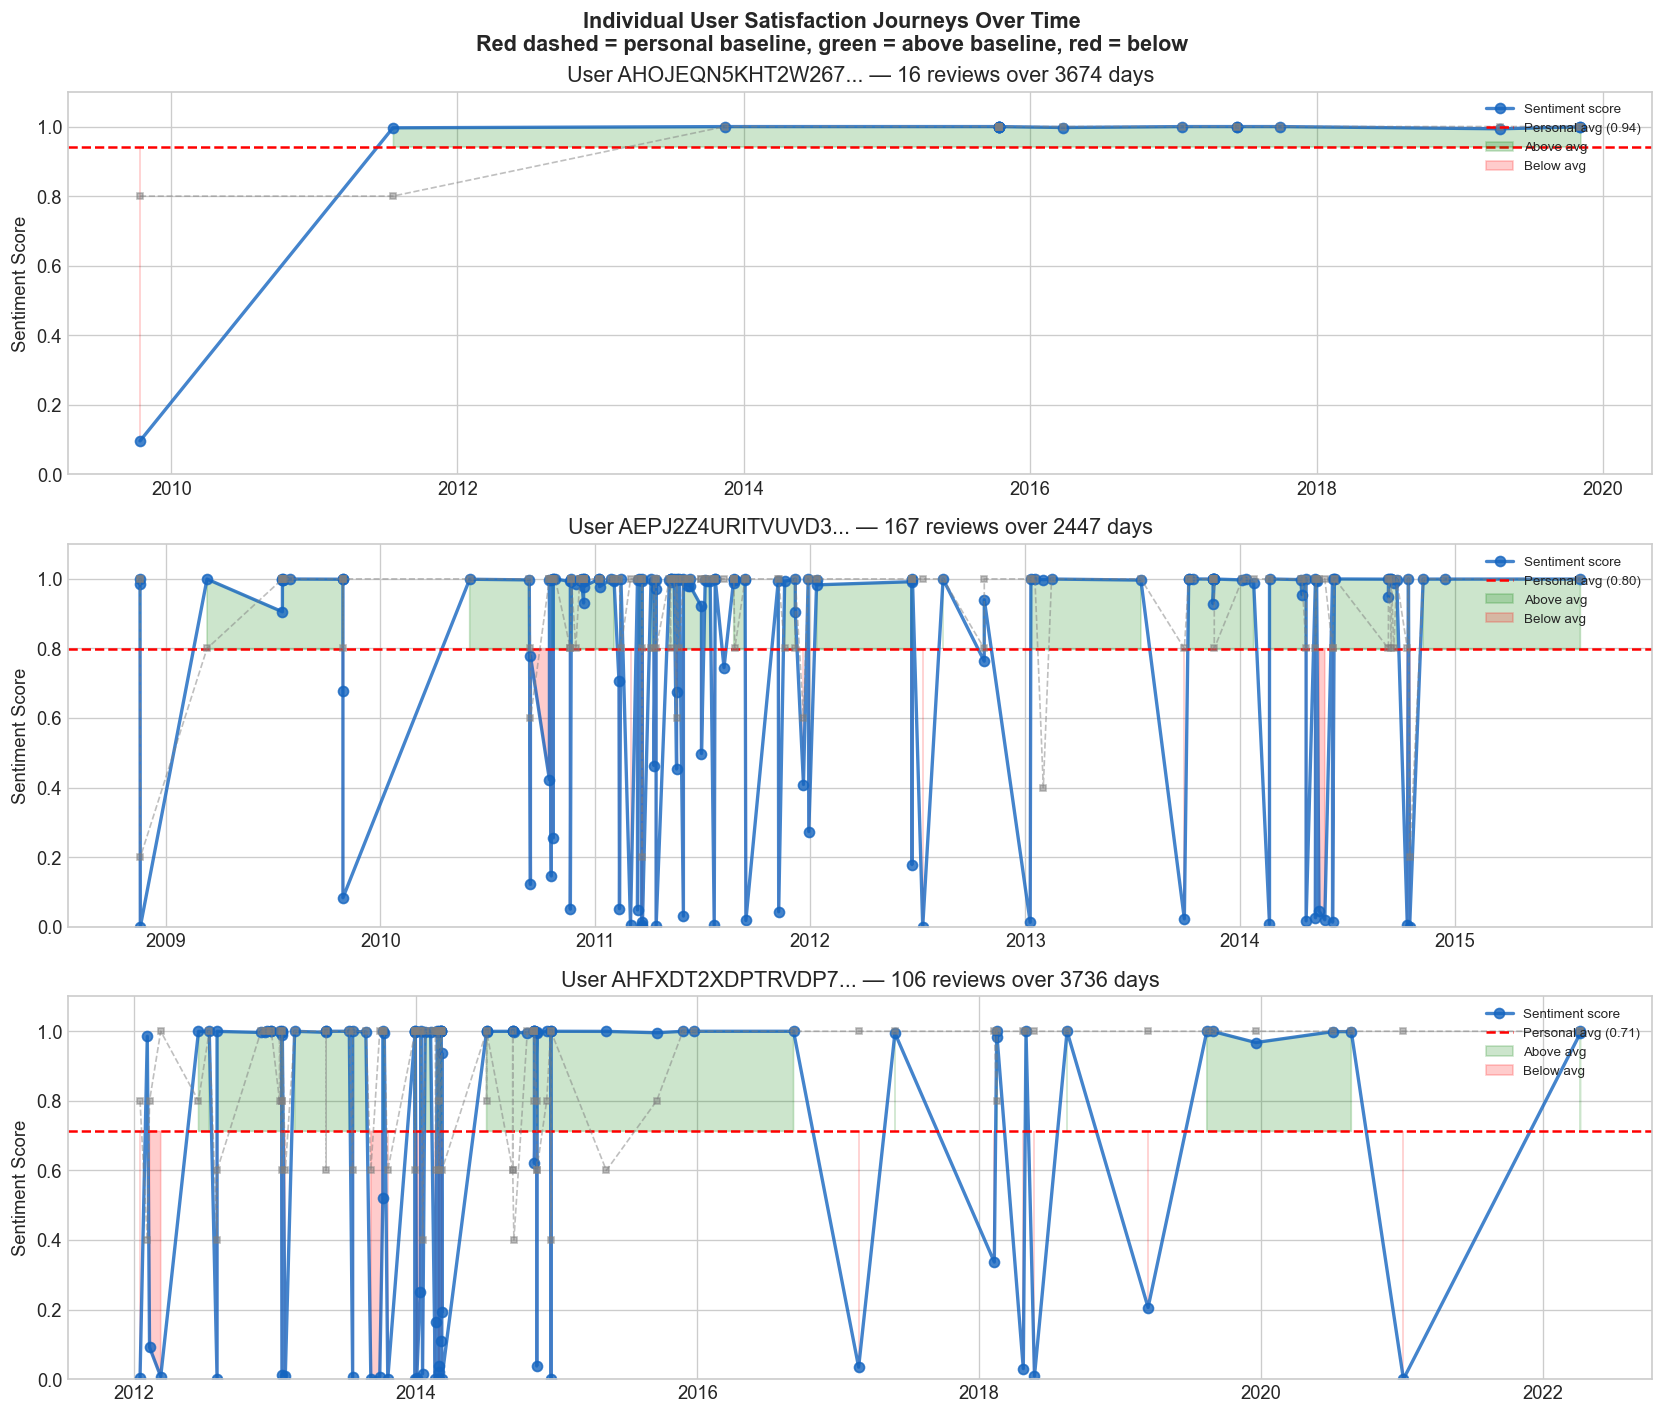

In [11]:
prolific_query = f"""
SELECT user_id, COUNT(*) as n
FROM {TABLE_ID}
GROUP BY user_id
HAVING n >= 15
ORDER BY RAND()
LIMIT 3
"""

prolific_users = client.query(prolific_query).to_dataframe()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for idx, (_, user_row) in enumerate(prolific_users.iterrows()):
    uid = user_row["user_id"]

    user_query = f"""
    SELECT rating, text, timestamp, text_len
    FROM {TABLE_ID}
    WHERE user_id = '{uid}'
    AND text_len >= 20
    ORDER BY timestamp
    """
    user_df = client.query(user_query).to_dataframe()
    user_df["ts"] = pd.to_datetime(user_df["timestamp"], unit="ms")

    if len(user_df) < 5:
        continue

    user_texts = user_df["text"].str[:512].tolist()
    user_results = sentiment_model(
        [t if t.strip() else "okay" for t in user_texts],
        batch_size=32
    )
    user_df["sentiment"] = [
        r["score"] if r["label"] == "POSITIVE" else 1 - r["score"]
        for r in user_results
    ]
    user_df["personal_avg"] = user_df["sentiment"].mean()

    # Convert to float for fill_between compatibility
    ts_num = mdates.date2num(user_df["ts"].dt.to_pydatetime())
    sentiment = user_df["sentiment"].values.astype(float)
    personal_avg = float(user_df["personal_avg"].iloc[0])

    ax = axes[idx]
    ax.plot(
        user_df["ts"], sentiment,
        "o-", color="#1565c0", linewidth=2,
        markersize=6, label="Sentiment score", alpha=0.8
    )
    ax.axhline(
        personal_avg, color="red", linestyle="--", linewidth=1.5,
        label=f"Personal avg ({personal_avg:.2f})"
    )
    ax.fill_between(
        ts_num, personal_avg, sentiment,
        where=sentiment >= personal_avg,
        alpha=0.2, color="green", label="Above avg"
    )
    ax.fill_between(
        ts_num, personal_avg, sentiment,
        where=sentiment < personal_avg,
        alpha=0.2, color="red", label="Below avg"
    )
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Sentiment Score")
    ax.set_title(
        f"User {uid[:16]}... — "
        f"{len(user_df)} reviews over "
        f"{(user_df['ts'].max() - user_df['ts'].min()).days} days"
    )
    ax.legend(loc="upper right", fontsize=8)
    ax.plot(
        user_df["ts"], user_df["rating"].values.astype(float) / 5,
        "s--", color="gray", linewidth=1,
        markersize=4, label="Rating/5", alpha=0.5
    )

plt.suptitle(
    "Individual User Satisfaction Journeys Over Time\n"
    "Red dashed = personal baseline, green = above baseline, red = below",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../notebooks/figures/06_user_journeys.png",
            bbox_inches="tight", dpi=150)
plt.show()

Individual users show clear personal satisfaction baselines. Some users are 
consistently positive reviewers (high baseline), others are more critical 
(lower baseline). Within each user, there is meaningful variation above and 
below their personal average.

The sentiment signal clearly captures more nuance than the star rating alone 
— users who gave 5 stars to everything still show sentiment variation in text.

**This confirms that personal sentiment deviation is a viable and meaningful 
reward signal for personalization.**